<img src = "img/images.png" style="height:80px;">
<div style="text-align:center;">
    
# Variables Cuantitativas

<img src ="img/Python-Logo.jpg" style="height:222px;">

    Marzo 27, 2026

</div>

### _Esteban Sáncez_

In [10]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,-28, -50, 60, -100, -10, -11, 13, 19, 1, 9])

In [11]:
# Medidas de tendencia central
from scipy import stats
media = np.mean(X)
mediana = np.median(X)
moda,_ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  -4.24375
mediana:  0.5
moda : 0.3


In [12]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt

Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC

print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)

RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


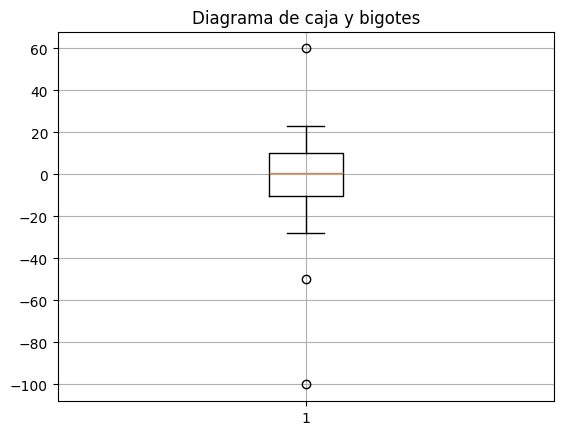

In [13]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de outliers
plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()

In [15]:
# Medidas de dispersión
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)

Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


In [16]:
# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [19]:
# Cargar el set de datos de Iris
from sklearn import datasets
from pprint import pprint
# pprint(iris)
iris = datasets.load_iris()
petalo_longitud = iris.data[:, 2]
sepalo_ancho    = iris.data[:, 1]

# Asimetría: longitud del pétalo
asimetria_petalo = stats.skew(petalo_longitud)
print(f"Asimetría longitud pétalo: {asimetria_petalo:.4f}")
if asimetria_petalo > 0:
    print("→ Asimetría positiva (cola a la derecha)")
elif asimetria_petalo < 0:
    print("→ Asimetría negativa (cola a la izquierda)")

print()

# Curtosis: ancho del sépalo
curtosis_sepalo = stats.kurtosis(sepalo_ancho)
print(f"Curtosis ancho sépalo: {curtosis_sepalo:.4f}")
if curtosis_sepalo > 0:
    print("→ Leptocúrtica (más apuntada que la normal)")
elif curtosis_sepalo < 0:
    print("→ Platicúrtica (más aplanada que la normal)")

Asimetría longitud pétalo: -0.2721
→ Asimetría negativa (cola a la izquierda)

Curtosis ancho sépalo: 0.1810
→ Leptocúrtica (más apuntada que la normal)


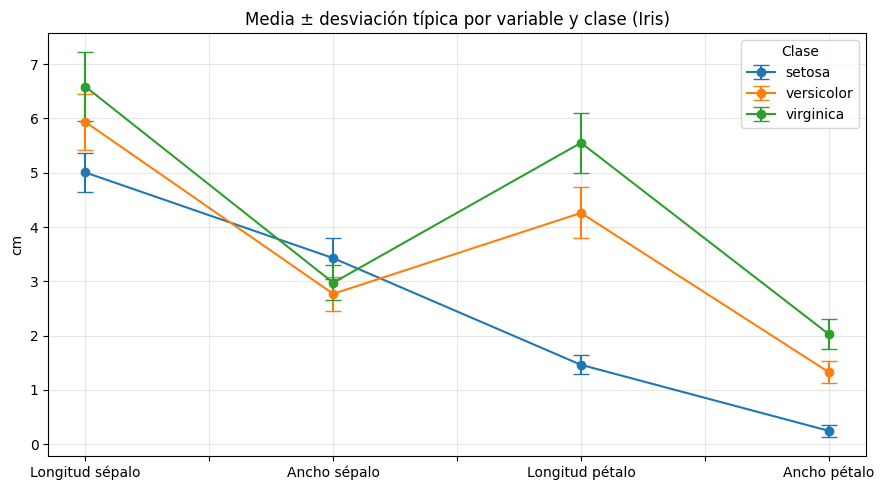

In [25]:
from sklearn import datasets
import pandas as pd
import matplotlib.pyplot as plt

iris = datasets.load_iris()

nombres_variables = ['Longitud sépalo', 'Ancho sépalo', 'Longitud pétalo', 'Ancho pétalo']

tabla = pd.DataFrame(iris.data, columns=nombres_variables)
tabla['clase'] = [iris.target_names[c] for c in iris.target]

medias       = tabla.groupby('clase')[nombres_variables].mean()
desviaciones = tabla.groupby('clase')[nombres_variables].std()

grafico = medias.T.plot(kind='line', marker='o', figsize=(9, 5),
                        yerr=desviaciones.T, capsize=6, elinewidth=1.5)

grafico.set_ylabel('cm')
grafico.set_title('Media ± desviación típica por variable y clase (Iris)')
grafico.legend(title='Clase')
grafico.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Repositorio en GitHub: https://github.com/EstebanSan140106/Machine-E-Learning-2.git